# Phase 0 — EDA: 데이터 구조 탐색

**목표:** `conversations.json`의 구조를 파악해 파서(Phase 1) 설계에 필요한 정보를 얻는다.

**개인정보 처리:**
- `data/` → `.gitignore` (원본 파일 업로드 안 됨)
- `nbstripout` git hook → 커밋 시 셀 출력 자동 제거

---

```
conversations.json
  └─ [ ] conversation
        ├─ uuid, name, created_at, updated_at
        └─ chat_messages[]
              ├─ uuid, sender, text, created_at
              └─ content[]
                    └─ block (type: text | thinking | tool_use | tool_result | token_budget)
```

내가 생각하기에 eda를 통해 답변할 수 있어야 하는 것

1. 무엇이 담겨있는가?(요소)
2. 어떻게 담겨있는가?(구성)

## 0. 데이터 로드

In [ ]:
import json
from pathlib import Path
from collections import Counter, defaultdict

DATA_DIR = Path('../data')

with open(DATA_DIR / 'conversations.json', encoding='utf-8') as f:
    conversations = json.load(f)

all_messages = [msg for c in conversations for msg in c['chat_messages']]
all_blocks   = [b for msg in all_messages for b in msg.get('content', [])]

print(f'대화:    {len(conversations)}')
print(f'메시지:  {len(all_messages):,}')
print(f'블록:    {len(all_blocks):,}')

## 1. 최상위 구조 — conversation 필드

In [ ]:
sample_conv = conversations[0]
for key, val in sample_conv.items():
    if key == 'chat_messages':
        print(f'  {key}: [{len(val)}개 메시지]')
    else:
        print(f'  {key}: {str(val)[:60]}')

## 2. 메시지 구조 — chat_message 필드

In [ ]:
sample_msg = all_messages[0]
for key, val in sample_msg.items():
    if key == 'content':
        print(f'  {key}: [{len(val)}개 블록]')
    else:
        print(f'  {key}: {str(val)[:60]}')

In [ ]:
# text 필드 vs content 블록의 text — 같은가 다른가?
# 파서에서 어느 쪽을 써야 할지 결정하기 위해 확인
mismatches = []
for msg in all_messages:
    content_text = ''.join(
        b.get('text', '') for b in msg.get('content', []) if b.get('type') == 'text'
    ).strip()
    top_text = msg.get('text', '').strip()
    if content_text and top_text and content_text != top_text:
        mismatches.append((top_text[:80], content_text[:80]))

print(f'text 필드 ≠ content text 블록: {len(mismatches)}건')
if mismatches:
    print('\n예시:')
    for top, content in mismatches[:2]:
        print(f'  top:     {top}')
        print(f'  content: {content}')
        print()

In [ ]:
# text 필드 vs content 블록의 text — 같은가 다른가?
# 파서에서 어느 쪽을 써야 할지 결정하기 위해 확인
mismatches = []
for msg in all_messages:
    content_text = ''.join(
        b.get('text', '') for b in msg.get('content', []) if b.get('type') == 'text'
    ).strip()
    top_text = msg.get('text', '').strip()
    if content_text and top_text and content_text != top_text:
        mismatches.append((top_text[:300], content_text[:300]))

print(f'text 필드 ≠ content text 블록: {len(mismatches)}건')
if mismatches:
    print('\n예시:')
    for top, content in mismatches[:1]:
        print(f'  top:     {top}')
        print()
        print('----- text 구분 -----')
        print()
        print(f'  content: {content}')
        print()

## 실제 위의 대화

위의 셀의 출력은 다음과 같다.

```
text 필드 ≠ content text 블록: 938건

예시:
  top:     좋아요! 코드를 모듈화하고 사용자 입력을 받도록 리팩토링해드릴게요. 깔끔하게 함수 단위로 분리하고, 설정을 유연하게 만들어보겠습니다.
```
Viewing artifacts created via the Analysis Tool web feature preview isn’t yet supported on mobile.
```

완성했습니다! 주요 개선사항은 다음과 같아요:

## 🎯 주요 변경사항

**1. 모듈화 구조**
- 각 기능을 독립적인 함수로 분리 (데이터 로드, 모델 설정, 추론, 저장)
- `Config` 클래스로 설정

----- text 구분 -----

  content: 좋아요! 코드를 모듈화하고 사용자 입력을 받도록 리팩토링해드릴게요. 깔끔하게 함수 단위로 분리하고, 설정을 유연하게 만들어보겠습니다.완성했습니다! 주요 개선사항은 다음과 같아요:

## 🎯 주요 변경사항

**1. 모듈화 구조**
- 각 기능을 독립적인 함수로 분리 (데이터 로드, 모델 설정, 추론, 저장)
- `Config` 클래스로 설정 관리
- 재사용 가능하고 테스트하기 쉬운 구조

**2. 사용자 입력 기능**
- 모델 ID 직접 입력 (기본값: zhihan1996/DNA_bert_6)
- 코돈 스페셜 토큰 사용 여부를 ye
```
top text와 content text가 서로 다른 경우의 대화 하나를 캡쳐해서 가져오면 다음과 같다.

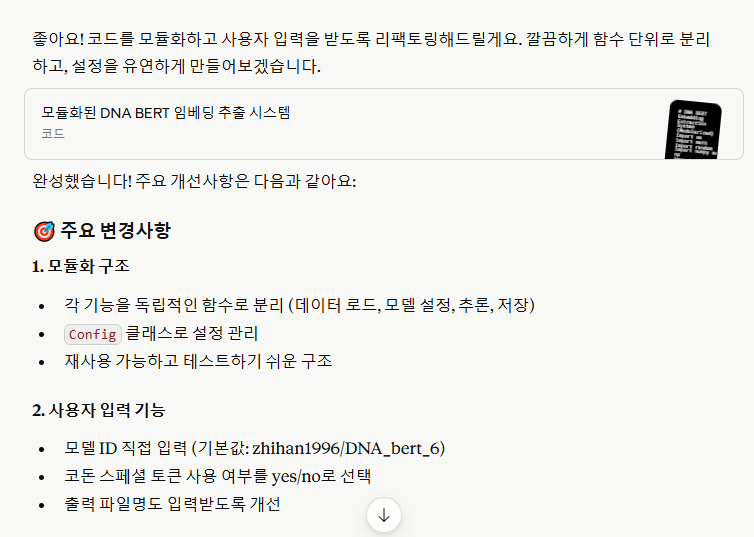

결론 : top_text는 전체적인 구조가 content_text에는 text만 들어가 있는 것으로 보인다.

질문
1. 그렇다면 전체적인 위치를 top_text로 잡는가?
2. text 외의 구성 요소들은 어떻게 되어 있는가?

## 3. 블록 타입별 필드 구조

파서가 각 타입을 처리할 때 어떤 필드를 읽어야 하는지 파악한다.

- 각 대화의 chat_messages 중 content 부분을 자세히 분석

In [ ]:
# 타입별 전체 필드 목록 (실제 데이터에서 나타난 모든 필드)
type_fields = defaultdict(set)
type_counts = Counter()
for b in all_blocks:
    t = b.get('type')
    type_fields[t].update(b.keys())
    type_counts[t] += 1

for t, cnt in type_counts.most_common():
    fields = sorted(type_fields[t])
    print(f'[{t}] ({cnt:,}개)')
    print(f'  필드: {fields}')
    print()

In [ ]:
# text 블록 예시
text_block = next(b for b in all_blocks if b.get('type') == 'text')
preview = dict(text_block)
preview['text'] = preview['text'][:100] + '...'
print(json.dumps(preview, ensure_ascii=False, indent=2))

- text 블럭은 우리가 가장 많이 보고 확인하는 블럭으로 이 프로젝트에서 가장 중요하게 처리 해야 하는 것을 확인할 수 있다.

In [ ]:
# thinking 블록 — text가 아닌 thinking 필드에 내용이 있음!
thinking_block = next(b for b in all_blocks if b.get('type') == 'thinking')
preview = dict(thinking_block)
preview['thinking'] = preview['thinking'][:100] + '...'
print(json.dumps(preview, ensure_ascii=False, indent=2))

- 클로드가 혼자서 생각하는 부분으로 RAG 이용시 점검 혹은 성능 향상으로 이어질 수 있는 부분으로 사용 가능할 것으로 보인다.

In [ ]:
# tool_use — artifacts 외 어떤 name이 있나?
tool_use_blocks = [b for b in all_blocks if b.get('type') == 'tool_use']
print('tool_use name 분포:')
for name, cnt in Counter(b.get('name') for b in tool_use_blocks).most_common():
    print(f'  {name}: {cnt}')

In [ ]:
# tool_use artifacts 예시
artifact_block = next(b for b in tool_use_blocks if b.get('name') == 'artifacts')
preview = dict(artifact_block)
preview['input'] = dict(preview['input'])
if 'content' in preview['input']:
    preview['input']['content'] = preview['input']['content'][:100] + '...'
print(json.dumps(preview, ensure_ascii=False, indent=2))

- 아래의 실제 대화 내역에서 확인할 수 있듯이 코드 파일과 같은 것들이 artifact에 담겨있는 것을 확인할 수 있다.

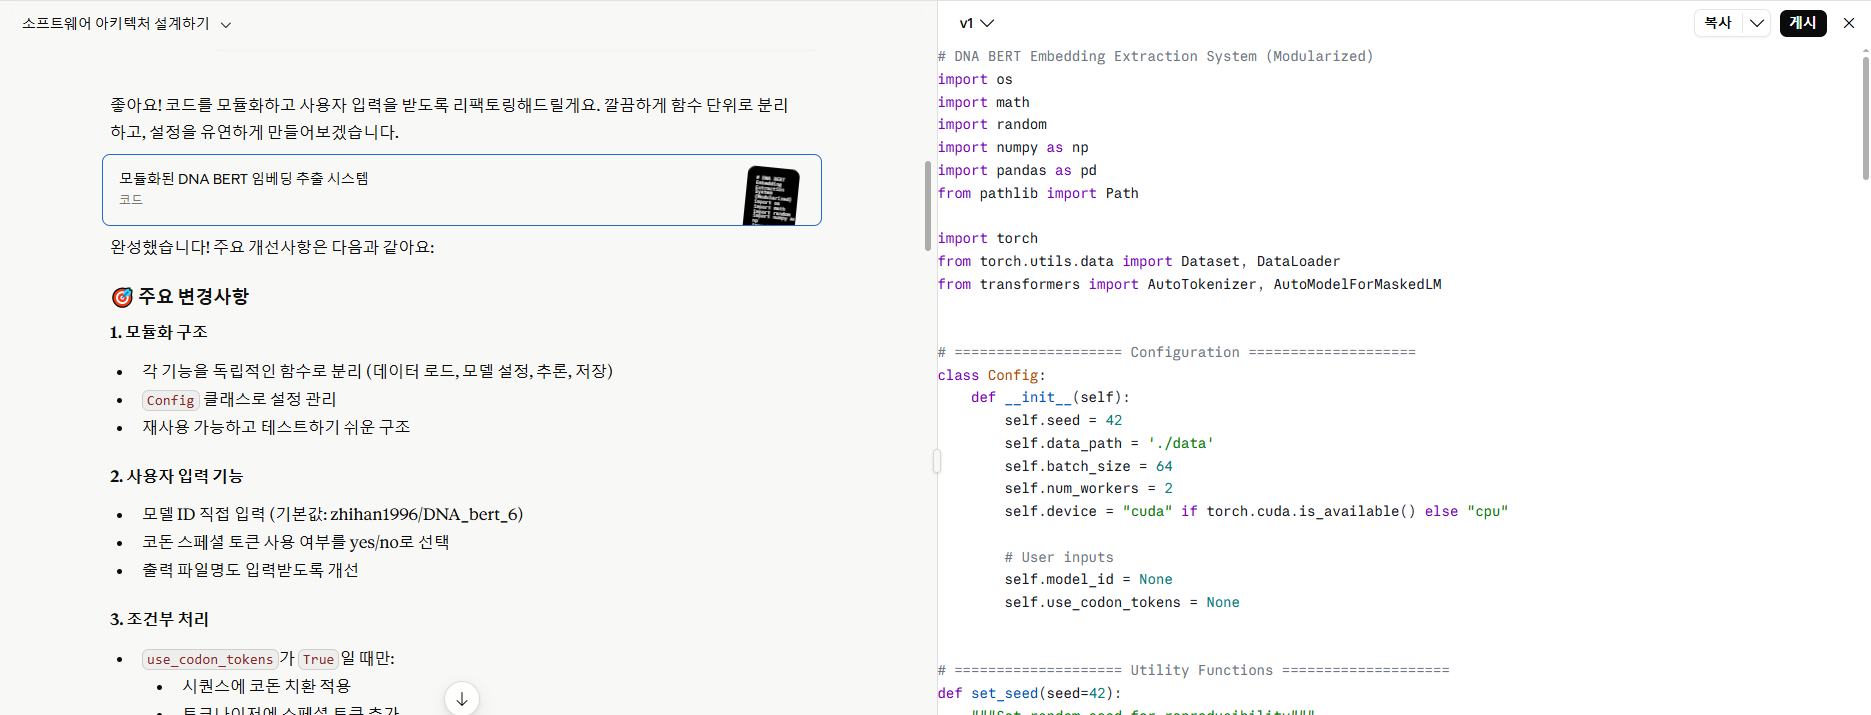

In [ ]:
# artifacts가 아닌 tool_use 예시 (웹검색 등)
other_tool = next((b for b in tool_use_blocks if b.get('name') != 'artifacts'), None)
if other_tool:
    preview = dict(other_tool)
    if 'input' in preview:
        preview['input'] = str(preview['input'])[:100]
    print(json.dumps(preview, ensure_ascii=False, indent=2))
else:
    print('artifacts 외 tool_use 없음')

- 위의 코드는 제너레이터 표션식으로 전체를 순회하지만, next()로 감싸는 순간 첫 번째 원소만 꺼내고 멈춤

In [ ]:
# 리스트 컴프리헨션으로 전부 수집
other_tools = [b for b in tool_use_blocks if b.get('name') != 'artifacts']

for tool in other_tools:
    preview = dict(tool)
    if 'input' in preview:
        preview['input'] = str(preview['input'])[:100]
    print(json.dumps(preview, ensure_ascii=False, indent=2))
    print('---')

- 추가로 확인했을 때 파일을 여닫고 생성하는 등의 메시지들이 담겨있는 것으로 확인되었다.
- ui를 클로드와 똑같이 만든다면 유의미할 것 같다. 
- 혹은 정말 세밀하게 어떤 파일들을 만들었었는지 체크하거나 프로젝트를 클로드 ai로 진행하는 경우에 유의미하게 사용할 수 있을 것으로 보인다.

In [ ]:
tool_use_blocks = [b for b in all_blocks if b.get('type') == 'tool_use']

for name, cnt in Counter(b.get('name') for b in tool_use_blocks).most_common():
    result = next((case for case in tool_use_blocks if case.get('name') == name), None)
    
    preview = dict(result)
    if 'input' in preview:
        preview['input'] = str(preview['input'])[:200]
    
    print(f'\n=== {name} (총 {cnt}개) ===')
    print(json.dumps(preview, ensure_ascii=False, indent=2))


- 모든 케이스 하나씩 뽑아서 확인했을 때 다음과 같은 메시지들로 예상된다.

  bash_tool: bash 명령어
  create_file: 파일 생성할 때 메시지
  web_search: 클로드가 웹에서 검색할 때 검색어 
  present_files: 클로드 내부 파일 위치
  view: 클로드 동작 메시지
  str_replace: 클로드 내부 동작 - 잘 모르겠음.
  visualize:show_widget: 클로드가 시각화할 때 메시지
  web_fetch: 웹사이트 링크
  artifacts: 코드 파일과 같은것들 
  visualize:read_me: 잘 모르겠음.
  ask_user_input_v0: 사용자 질문 메시지
  recommend_claude_apps: 잘 모르겠음.
  conversation_search: 클로드가 클로드 ai 내부에서 찾아본 동작
  message_compose_v1: 클로드 답변을 참조해서 질문하는 경우

- 이중에서 artifacts는 코드를 자세히 묻는 등 생성물에 대해서 자세히 검색하고 싶은 경우 사용 가능할 것으로 보인다.

In [ ]:
# tool_result — content 안에 또 타입이 있음
tool_result_blocks = [b for b in all_blocks if b.get('type') == 'tool_result']
inner_types = Counter(
    item.get('type') for b in tool_result_blocks for item in b.get('content', [])
)
print('tool_result.content 내부 타입:')
for t, cnt in inner_types.most_common():
    print(f'  {t}: {cnt:,}')

error_cnt = sum(1 for b in tool_result_blocks if b.get('is_error'))
print(f'\nis_error=True: {error_cnt}개 / {len(tool_result_blocks)}개')

In [ ]:
for t, cnt in inner_types.most_common():
    result = next(
        (item for b in tool_result_blocks for item in b.get('content', [])
         if item.get('type') == t),
        None
    )

    if result is None:
        print(f'\n=== {t} (총 {cnt}개) === 예시 없음')
        continue

    preview = dict(result)
    print(f'\n=== {t} (총 {cnt}개) ===')
    print(json.dumps(preview, ensure_ascii=False, indent=2))


- 분석 결과
  knowledge: 출처와 지식이 담겨있는 것으로 보임
  text: 잘 모르겠음.
  local_resource: 잘 모르겟음.
  image: 이미지로 보이나 클로드 내부에 이미지 이름으로 보임.

- text는 잘 모르겠으나 knowledge는 활용하기에 좋을 것 같음.


In [ ]:
# token_budget — 파서에서 무시해도 되는지 확인
token_budget_blocks = [b for b in all_blocks if b.get('type') == 'token_budget']
print(f'token_budget 블록 수: {len(token_budget_blocks)}')
print(json.dumps(token_budget_blocks[0], ensure_ascii=False, indent=2))

- token_budget은 잘 모르겠음. 토큰 비용 처리 관련으로 보임.

## 4. 엣지 케이스 확인

In [ ]:
# content가 없는 메시지
no_content = [msg for msg in all_messages if not msg.get('content')]
print(f'content 없는 메시지: {len(no_content)}개')

# 알 수 없는 블록 타입
known = {'text', 'thinking', 'tool_use', 'tool_result', 'token_budget'}
unknown = [b for b in all_blocks if b.get('type') not in known]
print(f'알 수 없는 블록 타입: {len(unknown)}개')
if unknown:
    print(Counter(b.get('type') for b in unknown))

## 5. artifact 분석 — RAG 포함 여부 결정

In [ ]:
artifacts = [
    {
        'artifact_type': b['input'].get('type', ''),
        'title': b['input'].get('title', ''),
        'char_len': len(b['input'].get('content', '')),
    }
    for b in tool_use_blocks if b.get('name') == 'artifacts'
]

print(f'artifact 수: {len(artifacts)}')
print()
print('타입 분포:')
for t, cnt in Counter(a['artifact_type'] for a in artifacts).most_common():
    print(f'  {t}: {cnt}')

In [ ]:
import statistics
lengths = sorted(a['char_len'] for a in artifacts)
n = len(lengths)

print('artifact content 길이 (문자 수):')
print(f'  최소:   {min(lengths):,}')
print(f'  평균:   {int(statistics.mean(lengths)):,}')
print(f'  p75:    {lengths[int(n*0.75)]:,}')
print(f'  p90:    {lengths[int(n*0.90)]:,}')
print(f'  최대:   {max(lengths):,}')
print()
print('토큰 추정 (÷3.5):')
print(f'  평균: ~{int(statistics.mean(lengths)/3.5):,}토큰')
print(f'  p90:  ~{int(lengths[int(n*0.90)]/3.5):,}토큰')
print(f'  최대: ~{int(max(lengths)/3.5):,}토큰')

## 6. 파서 설계 결론

위 탐색 결과를 바탕으로 직접 채워보세요.

In [ ]:
print('=== 파서 설계 메모 ===')
print()
print('Q1. text 필드 vs content 블록, 파서에서 뭘 써야 할까?')
print('  → content 블록을 사용하는 것이 더 좋을 것 같다고 생각한다. 하지만, text 필드로 재구성했을 때 어떻게 생겼는지 참조하는 것도 좋을 것 같다.')
print()
print('Q2. thinking 블록은 text가 아닌 thinking 필드에 있다. 파서에서 어떻게 처리?')
print('  → thinking 필드는 사용자 질문에 대해서 클로드가 요약 및 정리한 내용이 담겨있으므로 RAG에서 RAPTOR와 같은 것들로 이용이 가능할 것으로 보인다.')
print()
print('Q3. token_budget 블록은 RAG 컨텍스트에서 제외해도 되나?')
print('  → token_budget 블록은 토큰 비용처리 관련으로 제외해도 좋을 것으로 보인다.')
print()
print('Q4. artifact를 RAG에 포함할까? 포함한다면 어떤 방식으로?')
print('  → 포함하는 것이 좋지만, 코드를 묻는 경우에만 사용하는 것이 좋아보인다. 이유는 너무 많은 토큰을 필요로 한다.')
print()
print('Q5. 알 수 없는 블록 타입이 미래에 생기면 파서가 어떻게 해야 할까?')
print('  → tool_use 블록을 봤을 때, 나의 대화에서는 사용되지 않은 기능이 존재할 것으로 보인다. 만약 확장성있게 하려면 데이터 내보내기한 원본 데이터에서 파서할 때 감지 후 어떤 대화에서 이전과 다른 대화 블록이 있다는 것을 띄워주는 경고문만 내주는 식으로 하는 것이 좋을 것 같다.')

## 블록 타입 전체 레퍼런스

각 블록이 무엇인지, 어떤 필드를 갖는지, 뷰어/RAG에서 어떻게 쓸지 정리.

---

### text
**무엇인가:** Claude의 일반 텍스트 응답. 대화에서 가장 많은 비중.

**주요 필드:**
- `text` — 본문 내용
- `citations` — 출처 정보 (있을 때만)
- `start_timestamp`, `stop_timestamp` — 생성 시간

| 뷰어 | RAG |
|---|---|
| ✅ 그대로 렌더링 | ✅ 핵심 컨텍스트 |

---

### thinking
**무엇인가:** Claude Extended Thinking 기능이 켜졌을 때 생성되는 내부 추론 과정.
사용자에게 보이는 최종 답변이 아닌, Claude가 '혼자 생각한' 내용.

**주요 필드:**
- `thinking` — 추론 본문 (**text 필드가 아님!**)
- `summaries` — 요약본 (긴 thinking일 때)
- `cut_off`, `truncated` — 잘렸는지 여부
- `signature` — 변조 방지 서명

| 뷰어 | RAG |
|---|---|
| ✅ 기본 접힘(collapsed)으로 표시 | ❌ 제외 — 내부 추론이라 검색 컨텍스트에 불필요 |

---

### tool_use
**무엇인가:** Claude가 외부 도구를 호출한 기록. `name` 필드로 어떤 도구인지 구분.

**공통 필드:**
- `name` — 도구 종류
- `id` — tool_result와 매칭할 때 사용
- `input` — 도구에 전달한 입력값

#### name별 세부 분류

| name | 무엇인가 | input에 담긴 것 | 뷰어 | RAG |
|---|---|---|---|---|
| artifacts | 코드/문서/React 등 산출물 생성 | type, title, content (실제 코드/문서) | ✅ 코드 블록 렌더링 | 🔶 title+앞500자 별도 인덱스 |
| bash_tool | bash 명령 실행 | command | ✅ 명령어 표시 | ❌ |
| create_file | 파일 생성 | path, content | ✅ 파일명 표시 | ❌ |
| web_search | 웹 검색 | query | ✅ 검색어 표시 | ❌ |
| web_fetch | 웹페이지 가져오기 | url | ✅ URL 표시 | ❌ |
| str_replace | 파일 내 문자열 교체 (Claude Code) | path, old/new string | ✅ 간략 표시 | ❌ |
| view | 파일/디렉토리 조회 | path | ✅ 간략 표시 | ❌ |
| present_files | Claude 내부 파일 위치 안내 | paths | ✅ | ❌ |
| conversation_search | Claude.ai 내 대화 검색 | query | ✅ | ❌ |
| visualize:show_widget | 시각화 위젯 | 시각화 데이터 | ✅ 이미지/차트 | ❌ |
| visualize:read_me | 시각화 메타 | - | ✅ | ❌ |
| ask_user_input_v0 | 사용자 입력 요청 | 질문 내용 | ✅ | ❌ |
| message_compose_v1 | 이전 답변 참조 질문 | 참조 내용 | ✅ | ❌ |
| recommend_claude_apps | 앱 추천 | 추천 데이터 | ✅ | ❌ |

---

### tool_result
**무엇인가:** tool_use 실행 결과. `tool_use_id`로 어떤 tool_use의 결과인지 매칭.

**공통 필드:**
- `tool_use_id` — 대응하는 tool_use의 id
- `content` — 결과 배열 (내부에 또 타입이 있음)
- `is_error` — 에러 발생 여부

#### content 내부 타입별 세부 분류

| content type | 무엇인가 | 뷰어 | RAG |
|---|---|---|---|
| knowledge | 웹검색 결과 — 출처 URL + 본문 텍스트 | ✅ 출처 링크 + 본문 | 🔶 포함 고려 (실제 정보 담김) |
| text | 도구 실행 결과 텍스트 (bash 출력, 파일 내용 등) | ✅ 코드블록 표시 | ❌ 대부분 불필요 |
| local_resource | 사용자 업로드 파일/이미지 | ✅ 파일명/이미지 | ❌ |
| image | 이미지 데이터 | ✅ 이미지 렌더링 | ❌ |

---

### token_budget
**무엇인가:** Extended Thinking 사용 시 남은 토큰 예산을 추적하는 메타데이터 블록.
대화 내용이 아닌 API 내부 관리용 정보.

**주요 필드:**
- `remaining` — 남은 토큰 수

| 뷰어 | RAG |
|---|---|
| ❌ 표시 불필요 | ❌ 제외 |

---

### 요약 — 파서가 보존해야 할 것

```
뷰어용:  모든 블록 타입 보존 (token_budget 제외)
RAG용:   text 블록 필수
         artifacts title+앞500자 선택적
         tool_result knowledge 선택적
         나머지 제외
알수없는 타입: RawBlock으로 보존 (경고 로그 출력)
```


---
# 피드백 및 분석

> 아래는 EDA 전체를 검토한 후 작성한 피드백, 활용 방향, 파서 설계 계획이다.
> 직접 수정·반박해가며 읽는 것을 권장한다.

## 잘한 점

**1. EDA 목적 프레이밍 (cell 1)**
"무엇이 담겨있는가 / 어떻게 담겨있는가" 두 질문으로 목적을 먼저 정리한 것이 좋다. EDA는 목적 없이 탐색하면 산만해지는데, 이 프레임이 전체 방향을 잡아줬다.

**2. text 불일치 938건 발견 (cell 9-10)**
단순히 코드를 실행하는 데 그치지 않고, 출력 길이를 300자로 늘려 직접 내용을 확인했다. 이것이 EDA의 핵심이다. 이 발견이 파서 설계에서 가장 중요한 결정 근거가 된다.

**3. tool_use 14종 전수 조사 (cell 24-25)**
로 첫 번째만 보는 코드를 리스트 컴프리헨션으로 직접 바꿔서 전체를 확인했다. Python 동작 원리도 메모해뒀다. 이 정도 탐색 깊이는 충분히 포트폴리오 가치가 있다.

**4. thinking 블록 → RAPTOR 연결 아이디어 (cell 16)**
데이터를 보고 활용 가능성을 스스로 연결한 점이 좋다. 아이디어 자체도 나쁘지 않다.

## 보완할 점

**1. text 불일치의 원인 미분석**
938건 발견에서 멈췄는데, 왜 다른지 원인까지 파고드는 것이 좋다.
실제 원인: `text` 필드에는 `"Viewing artifacts created via the Analysis Tool web feature preview isn't yet supported on mobile."` 같은 **모바일 UI용 플레이스홀더 문자열**이 삽입된다.
즉 `text` 필드는 UI 렌더링용이고, `content` 블록이 실제 구조화된 데이터다. → **파서는 반드시 `content` 블록 사용**

**2. tool_use ↔ tool_result 페어링 미확인**
`tool_use`에 `id` 필드, `tool_result`에 `tool_use_id` 필드가 있다. 이 둘이 실제로 매칭되는지 확인하지 않았다.
파서에서 tool_use와 tool_result를 짝지어 처리할 때 필요한 정보다.

**3. tool_result 내부 타입 `text` / `local_resource` 미분석**
"잘 모르겠음"으로 남겼는데:
- `text`: 웹검색/bash 실행 결과가 텍스트로 반환되는 것
- `local_resource`: 사용자가 업로드한 파일/이미지
- `knowledge`: 웹검색 결과 (출처 + 본문) → RAG에 포함 가치 있음

**4. thinking → RAPTOR 연결은 약간 부정확**
RAPTOR는 문서 계층 요약 검색 기법이고, thinking은 Claude가 생성한 내부 추론이다.
아이디어 방향은 좋지만 지금 단계에서는 "뷰어에서 접힘 처리, RAG 컨텍스트 제외"로 먼저 쓰는 것이 현실적이다.


## 내 분석 — 파서 설계에 쓸 결론

### text 필드 vs content 블록
```
결론: content 블록 사용
이유: text 필드는 모바일 UI 렌더링용으로 artifact 플레이스홀더가 섞임
     content 블록은 타입별로 구조화된 실제 데이터
```

### 블록 타입별 파서 처리 방향

| 타입 | 파서 처리 | RAG 포함 |
|---|---|---|
| text | block['text'] 읽기 | ✅ 핵심 컨텍스트 |
| thinking | block['thinking'] 읽기 (필드명 주의!) | ❌ 제외 (내부 추론) |
| tool_use (artifacts) | input.type, input.title, input.content | 🔶 결정 필요 |
| tool_use (나머지) | name 기록 정도 | ❌ 제외 |
| tool_result (knowledge) | 출처 + 본문 | 🔶 포함 고려 |
| tool_result (나머지) | 기록 정도 | ❌ 제외 |
| token_budget | 무시 | ❌ 제외 |

### artifact RAG 포함 여부 — 내 판단

Q4에서 '코드 질문에만 사용'이라고 판단했는데 방향이 맞다.
조금 더 구체화하면:
- artifact 전체 포함 → Groq rate limit 부담 (평균 수천 자, p90 수만 자)
- 권장: title + content 앞 500자를 별도 인덱스로 구성
  - 검색에는 요약본 사용, 히트 시 원본 전달 (Small-to-Big)
  - Phase 5 평가 후 전략 조정

### Q5 미래 블록 타입 대응 — 판단 보완

경고문 출력 아이디어가 좋다. 조금 더 구체화하면:
```
알 수 없는 타입 감지 → 경고 로그 출력
                    → RawBlock(type=unknown, raw=원본) 으로 보존
                    → RAG 컨텍스트에서는 제외
```
이렇게 하면 새 타입이 생겨도 파서가 죽지 않고, 나중에 지원을 추가할 수 있다.

### tool_use ↔ tool_result 페어링 확인 (미완성 — 직접 실행)
```python
tool_use_ids = {b['id'] for b in all_blocks if b.get('type') == 'tool_use' and b.get('id')}
tool_result_ids = {b.get('tool_use_id') for b in all_blocks if b.get('type') == 'tool_result'}
print(f'tool_use id 수: {len(tool_use_ids)}')
print(f'tool_result tool_use_id 수: {len(tool_result_ids)}')
print(f'매칭 안 되는 tool_use: {len(tool_use_ids - tool_result_ids)}')
```


## Phase 1 파서 설계 계획

이 EDA 결과를 바탕으로 파서가 해야 할 일:



**models.py에서 정의할 Pydantic 모델:**
- , , , , 
- 
- 

**다음 단계 (Phase 1 시작 전 할 것):**
1. tool_use ↔ tool_result 페어링 확인 (위 코드 실행)
2. Q4 artifact RAG 결정 완성
3. 이 노트북 커밋 → solution 브랜치에서 parser.py + models.py 구현

# 추가) 페어링 확인

In [ ]:
tool_use_ids = {b['id'] for b in all_blocks if b.get('type') == 'tool_use' and b.get('id')}
tool_result_ids = {b.get('tool_use_id') for b in all_blocks if b.get('type') == 'tool_result'}
print(f'tool_use id 수: {len(tool_use_ids)}')
print(f'tool_result tool_use_id 수: {len(tool_result_ids)}')
print(f'매칭 안 되는 tool_use: {len(tool_use_ids - tool_result_ids)}')

In [ ]:
unmatched_ids = tool_use_ids - tool_result_ids

unmatched_blocks = [b for b in all_blocks if b.get('id') in unmatched_ids]

print(f'매칭 안 되는 tool_use: {len(unmatched_blocks)}개')
print()

name_dist = Counter(b.get('name') for b in unmatched_blocks)
print('name 분포:')
for name, cnt in name_dist.most_common():
    print(f'  {name}: {cnt}')

- 파일 생성 부분에서 매칭이 안됨. 중요한 것은 아니라고 판단

In [ ]:
# tool_result 중 대응하는 tool_use가 없는 경우
unmatched_results = tool_result_ids - tool_use_ids
print(f'매칭 안 되는 tool_result: {len(unmatched_results)}개')


In [ ]:
unmatched_result_id = (tool_result_ids - tool_use_ids).pop()
unmatched_block = next(b for b in all_blocks 
                       if b.get('tool_use_id') == unmatched_result_id)
print(unmatched_block.get('name'))
print(unmatched_block.get('tool_use_id'))


- tool_result 1개에 tool_use_id = None → 데이터 결함, 파서에서 None 체크만 추가